# 1. 层和块
单个神经网络可以完成以下几项工作：</br>
1. 接收一些输入；</br>
2. 生成相应的标量输出；</br>
3. 具有一组相关参数，更新这些参数可以优化某些目标函数。</br>

当考虑具有多个输出的网络时，我们利用向量化来描述整层神经元。像单个神经元一样，**层**完成以下几项工作：</br>
1.接收一组输入；</br>
2.生成相应的输出；</br>
3.由一组可调整参数描述。</br>

对多层感知机而言，整个模型及其组成层都是这种架构。整个模型接收原始输入（特征），生成输出（预测），并包含一些参数（所有组成层的参数集合）。同样，每个单独层接收输入（由前一层提供），生成输出（到下一层的输入），并且具有一组可调的参数，这些参数根据从下一层反向传播的信号进行更新。

但事实证明，研究讨论“比单个层大”但“比整个模型小”的组件更有价值。例如**ResNet-152**。

为了实现这些复杂的网络，我们引入神经网络块的概念。**块**可以描述单个层、由多个层组成的组件或整个模型本身。使用块的好处：**是可以将一些块组合成更大的组件，这一过程通常是递归的，如下图所示。**

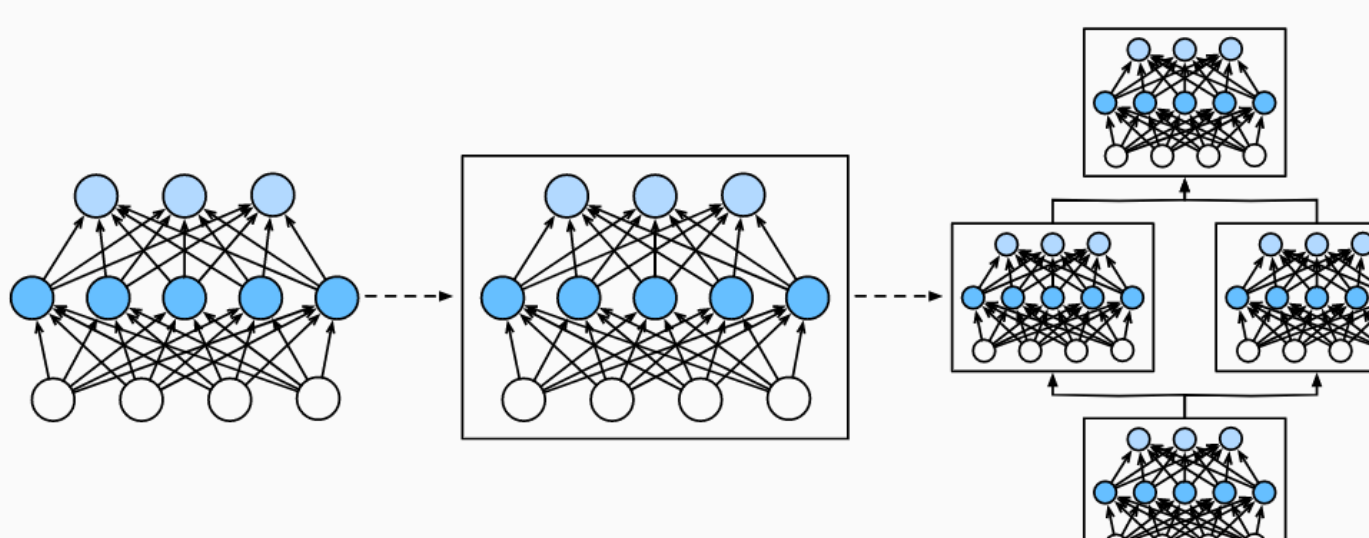

从编程的角度来看，块由类（class）表示，类的任何子类都必须定义一个将其输入转换为输出的前向传播函数，并且必须存储任何必需的参数。但不是所有的块都需要参数。最后为了计算梯度，块必须具有反向传播函数。在自定义块时，由于自动微分提供了一些后端实现，我们只需要考虑前向传播函数和必需的参数。

下面的代码 生成一个网络，其中包含一个具有256个单元和ReLU激活函数的全连接隐藏层，以及一个具有10个隐藏单元且不带有激活函数的全连接输出层。

In [2]:
import torch
from torch import nn
from torch.nn import functional as F

net = nn.Sequential(nn.Linear(20, 256), nn.ReLU(), nn.Linear(256, 10))

X = torch.rand(2, 20) # 2 个样本，每个样本有 20 个特征
net(X)

tensor([[-1.9214e-01,  2.0440e-01, -3.6269e-04,  1.0934e-01, -1.2510e-01,
          1.1209e-01,  5.2496e-02, -1.4557e-01,  1.3044e-01,  1.2366e-01],
        [-3.9401e-01,  1.9729e-01, -9.5231e-02,  5.7156e-02, -2.3505e-01,
          6.0426e-02, -1.9784e-02, -1.3604e-01,  1.3081e-01,  1.0573e-01]],
       grad_fn=<AddmmBackward0>)

我们通过实例化nn.Sequential来构建模型，层的执行顺序是作为参数传递的。简而言之，nn.Sequential定义了一种特殊的Module，即在Pytorch中作为一个块的类，它维护一个由Module组成的有序列表。两个全连接层都是Linear类的实例，Linear类本身就是Module的子类。net(X)实际上是net.__call__(X)的简写。

## 1.1 自定义块
我们简要总结一下块必须提供的基本功能。</br>
1.将输入数据作为其前向传播函数的参数；</br>
2.通过前向传播函数来申城输出，输出的形状不一定和输入的形状一致；</br>
3.计算其输出关于输入的梯度，可通过其反向传播函数进行访问。通常是自动完成的；</br>
4.存储和访问前向传播计算所需的参数；
5.根据需要初始化模型参数。

In [4]:
class MLP(nn.Module):
    # 用模型参数声明这里，我们声明两个全连接层
    def __init__(self):
        # 调用MLP的父类Module的构造函数来执行必要的初始化
        # 这样，在类实例化时也可以指定其他函数参数，例如模型参数params
        super().__init__() # 省去重复编写模板代码的麻烦
        self.hidden = nn.Linear(20, 256) # 隐藏层
        self.out = nn.Linear(256, 10)

    # 定义模型的前向传播，即如何根据输入x返回模型所需的输出
    def forward(self, x):
        # 注意，这里我们使用ReLU的函数版本，其在nn.functional模块中定义
        return self.out(F.relu(self.hidden(X)))

In [5]:
net = MLP()
net(X)

tensor([[-0.0402, -0.0760, -0.2213,  0.1501,  0.0515,  0.0134,  0.0148,  0.0450,
          0.1235,  0.2363],
        [ 0.0303, -0.1327, -0.1831,  0.0725, -0.0109,  0.0459,  0.0829,  0.0652,
          0.0084,  0.1647]], grad_fn=<AddmmBackward0>)

块的一个主要特点是它的多功能性。我们可以子类化块以创建层、整个模型或具有中等复杂度的各种组件。

## 1.2 顺序块
现在我们可以看看Sequential类是如何工作的，回想一下Sequential的设计目的是把其他模块串起来。为了构建子集的简化的MySequential，只需要定义下面两个关键函数。</br>
1.将块逐个追加到列表中的函数；</br>
2.前向传播函数，用于将输入按追加块的顺序传递给块组成的“链条”。</br>

In [9]:
class MySequential(nn.Module):
    def __init__(self, *args):
        super().__init__() # 调用父类构造函数，初始化 _modules 等内部属性
        for idx, module in enumerate(args): # enumerate(args) 是 Python 的内置函数，用于同时获取元素的索引和值。
            # module是Module子类的一个实例我们把他保存在Module类的成员
            # 变量_Modules中 它的类型是OrderedDict
            self._modules[str(idx)] = module
    
    def forward(self, X):
        # OrderedDict保证了按照成员添加的顺序遍历它们
        for block in self._modules.values():
            X = block(X)
        return X

_modules的主要特点是：在模块的参数初始化过程中，系统直到在_modules字典中查找需要初始化参数的子块。

In [10]:
net = MySequential(nn.Linear(20, 256), nn.ReLU(), nn.Linear(256, 10))
net(X)

tensor([[ 0.0270,  0.0465, -0.1714,  0.2050,  0.1954,  0.1296,  0.0108, -0.0061,
          0.2191,  0.2293],
        [ 0.0111,  0.0538, -0.2193,  0.3074,  0.2498,  0.1091,  0.1739,  0.0590,
          0.0646,  0.2709]], grad_fn=<AddmmBackward0>)

并不是所有的架构都是简单的顺序架构。

到目前为止，网络中的所有操作都对网络的激活值及网络的参数起作用。然而，有时我们可能希望合并既不是上一层的结果也不是可更新参数的项，我们称之为**常数参数**。例如，我们需要设计一个计算函数$f(x,w)=c \cdot w^T x$的层，其中x是输入，w是参数，c是某个在优化过程中没有更新的指定常量。

In [13]:
class FixedHiddenMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 不计算梯度的随机权重参数，因此其在训练期间保持不变
        self.rand_weight = torch.rand((20, 20), requires_grad = False)
        self.linear = nn.Linear(20, 20)

    def forward(self, X):
        X = self.linear(X)
        # 使用创建的常量参数以及relu和mm函数
        X = F.relu(torch.mm(X, self.rand_weight) + 1)
        # 复用全连接层这相当于两个全连接层共享参数
        X = self.linear(X)
        # 控制流
        while X.abs().sum() > 1:
            X /= 2
        return X.sum()

In [14]:
net = FixedHiddenMLP()
net(X)

tensor(-0.3110, grad_fn=<SumBackward0>)

我们可以混合搭配葛总组合块的方法。

In [17]:
class NestMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(20, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU())

        self.linear = nn.Linear(32, 16)

    def forward(self, X):
        return self.linear(self.net(X))

chimera = nn.Sequential(NestMLP(), nn.Linear(16, 20), FixedHiddenMLP())
chimera(X)

tensor(-0.2045, grad_fn=<SumBackward0>)

比较关心的是效率问题，而Python中最重要的就是**全局解释器锁**。</br>
全局解释器锁（GIL） 是Python解释器（特别是CPython实现）中的一个机制，用于确保线程安全。它限制了多线程的并行性，但在某些场景下也有其必要性。</br>
GIL的定义与工作原理：</br>
GIL是一种全局锁，用于防止多个线程同时执行Python字节码。由于Python的内存管理不是线程安全的，GIL通过互斥锁的方式，确保任意时刻只有一个线程可以执行Python代码。对于CPU密集型任务，这种机制会限制多线程的性能提升，但对于IO密集型任务，线程在等待IO时会释放GIL，从而允许其他线程执行。

在深度学习环境中，我们担心极快的GPU可能等到CPU执行Python代码后才能执行另一个作业。